In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
# Load Nigeria shapefile (level 1 = states)
# Why: gadm41_NGA_1.shp contains all 36 Nigerian states as separate shapes
nigeria = gpd.read_file("data/raw/gadm41_NGA_1.shp")

In [4]:
# See all state names
# Why: confirms the file loaded correctly and shows us exact state name spelling
print(nigeria['NAME_1'].unique())

<StringArray>
[                     'Abia',                   'Adamawa',
                 'Akwa Ibom',                   'Anambra',
                    'Bauchi',                   'Bayelsa',
                     'Benue',                     'Borno',
               'Cross River',                     'Delta',
                    'Ebonyi',                       'Edo',
                     'Ekiti',                     'Enugu',
 'Federal Capital Territory',                     'Gombe',
                       'Imo',                    'Jigawa',
                    'Kaduna',                      'Kano',
                   'Katsina',                     'Kebbi',
                      'Kogi',                     'Kwara',
                     'Lagos',                  'Nasarawa',
                     'Niger',                      'Ogun',
                      'Ondo',                      'Osun',
                       'Oyo',                   'Plateau',
                    'Rivers',             

In [5]:
# Filter Ondo State only
# Why: we only want to work with Ondo, not all of Nigeria
ondo = nigeria[nigeria['NAME_1'] == 'Ondo']

In [6]:
# Save Ondo boundary as its own shapefile
# Why: we'll use this boundary in every future analysis step
ondo.to_file("data/raw/ondo_boundary.shp")
print("✅ Ondo State boundary saved!")


✅ Ondo State boundary saved!


✅ Map saved to outputs/ondo_boundary.png


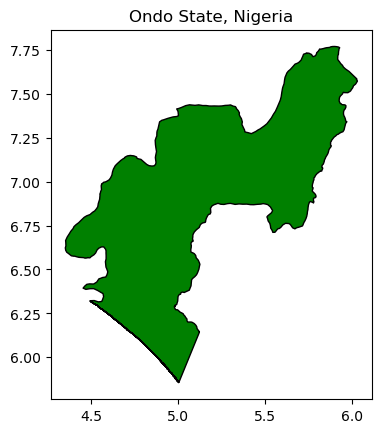

In [7]:
# Plot and save the map
ondo.plot(color='green', edgecolor='black')
plt.title("Ondo State, Nigeria")
plt.savefig("outputs/ondo_boundary.png", dpi=150)
print("✅ Map saved to outputs/ondo_boundary.png")

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# File paths
# Why: Band 4 = Red light, Band 5 = Near-Infrared
# Healthy vegetation absorbs red light and reflects near-infrared strongly
b4_path = "data/raw/LC08_L2SP_190055_20151217_20200908_02_T1_SR_B4.TIF"
b5_path = "data/raw/LC08_L2SP_190055_20151217_20200908_02_T1_SR_B5.TIF"

In [3]:
# Load the bands
with rasterio.open(b4_path) as b4:
    red = b4.read(1).astype(float)
    profile = b4.profile


In [4]:
with rasterio.open(b5_path) as b5:
    nir = b5.read(1).astype(float)


In [5]:
# Calculate NDVI
# Why: NDVI ranges from -1 to 1
# Values above 0.3 = healthy vegetation/forest
# Values near 0 = bare soil or urban area
# Negative values = water
ndvi = (nir - red) / (nir + red + 1e-10)

In [6]:
# Save NDVI result
profile.update(dtype=rasterio.float32, count=1)
with rasterio.open("outputs/ndvi_2015.tif", 'w', **profile) as dst:
    dst.write(ndvi.astype(np.float32), 1)

In [7]:
print(f"✅ NDVI calculated!")
print(f"Min NDVI: {ndvi.min():.2f}")
print(f"Max NDVI: {ndvi.max():.2f}")
print(f"Mean NDVI: {ndvi.mean():.2f}")

✅ NDVI calculated!
Min NDVI: -0.10
Max NDVI: 0.50
Mean NDVI: 0.22


✅ NDVI map saved to outputs/ndvi_2015.png


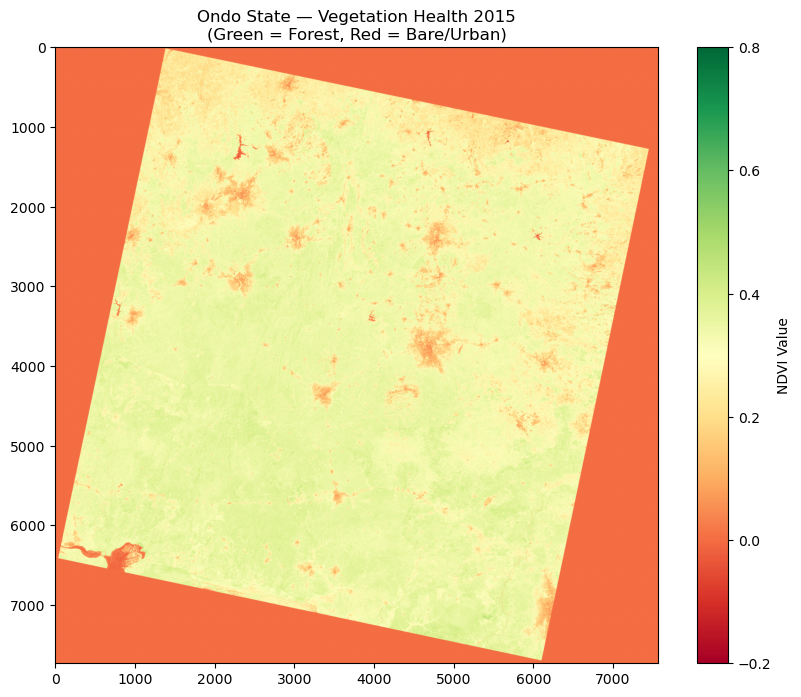

In [8]:
# Plot the NDVI map
plt.figure(figsize=(10, 8))
plt.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
plt.colorbar(label='NDVI Value')
plt.title('Ondo State — Vegetation Health 2015\n(Green = Forest, Red = Bare/Urban)')
plt.savefig("outputs/ndvi_2015.png", dpi=150, bbox_inches='tight')
print("✅ NDVI map saved to outputs/ndvi_2015.png")